#NOTE

In [1]:
#analisi fatta in ambiente google drive
# con la versione anaconda ha funzionato

In [2]:
# SI FA UNA ANALISI DI REGRESSIONE LINEARE MULTIPLA

# LIBRERIE

In [1]:
#librerie di base
import pandas as pd
import numpy as np

In [ ]:
#libreria per l'analisi dei dati
import statsmodels.api as sm
#from sklearn.linear_model import LinearRegression as lr

In [3]:
#libreria di supporto per l'analisi

# per lo scaling delle variabili numeriche
from sklearn.preprocessing import StandardScaler
# per eseguire il trainin e il test e la valutazione del modello
from sklearn.model_selection import train_test_split as envtest

In [4]:
#librerie di valutazione e misurazione del modello
from sklearn import metrics

In [5]:
#librerie grafiche
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

In [6]:
# =============================================================
# =============================================================
#
# importo le funzioni personali creati per questa fase


#aggiunto quando ho spostato i file in una cartella a parte
import sys
sys.path.append("./Moduli")

import Moduli.Modulo_Common as pd_common

#RECUPERO DATI

In [7]:
#caso google 
# df_incidenti = pd.read_csv( ".//Analisi//Incidenti_flat.csv")
df_incidenti = pd.read_csv( pd_common.GetFolderAnalisi()+ "//Incidenti_flat.csv")

In [10]:
df_incidenti.head(4)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,COMUNE,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE
0,0,0,2010,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2622,199.45,F,Feriti,14
1,1,1,2011,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2615,198.92,F,Feriti,6
2,2,2,2012,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2657,202.11,F,Feriti,8
3,3,3,2013,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2722,207.06,F,Feriti,5


In [11]:
df_incidenti.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

In [12]:
df_incidenti.TIME_PERIOD.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2017])

In [8]:
df_incidenti = df_incidenti.drop('Unnamed: 0', axis=1)

In [14]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

#PREPARAZIONE DATAFRAME DI ANALISI

##AMBITO DATI (CONTENUTO E TRASFORMAZIONI)

In [9]:
#feature : variabili indipendenti:  'TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT'
#   NB le altre sono relazionate tra loro per cui le derivo semplicemente sapendo una di quelle considerate come feature
#   NB COME FATTO IN SCRIPT PRECEDENTE LE VARIABILI IND. POP_RES E AREA_KMQ SONO STATE RIDOTTE A UNA SOLA POP_AL_KMQ CHE RACCOGLIE AMBEDUE LE INFORMAZIONI
#     RIDUCENDO GLI EFFETTI NEGATIVI DI INSERIRE PIù FEATURE E DOVE CORREGGERE IL RELATIVO EFFETTO - ES R QUADRO ADJUSTMENT
# variabile target: variabile dipendente: 'OBS_VALUE'
df_analisi = df_incidenti[['index','TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT','OBS_VALUE']]

In [10]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118111 entries, 0 to 118110
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        118111 non-null  int64  
 1   TIME_PERIOD  118111 non-null  int64  
 2   PRO_COM      118111 non-null  int64  
 3   POP_AL_KMQ   118111 non-null  float64
 4   RESULT       118111 non-null  object 
 5   OBS_VALUE    118111 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 5.4+ MB


In [11]:
df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')

C:\Users\pietr\AppData\Local\Temp\ipykernel_26108\2194147801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')


In [12]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118111 entries, 0 to 118110
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        118111 non-null  int64  
 1   TIME_PERIOD  118111 non-null  int64  
 2   PRO_COM      118111 non-null  int64  
 3   POP_AL_KMQ   118111 non-null  float64
 4   RESULT       118111 non-null  string 
 5   OBS_VALUE    118111 non-null  int64  
dtypes: float64(1), int64(4), string(1)
memory usage: 5.4 MB


In [13]:
# LA COLONNA TESTUALE LA CONVERTO IN UNA FEATURE BOOLEAN
# SICCOME IL DOMINIO VALORI AMMESSO E' DI SOLO 2 VALORI CREO UNA SOLA COLONNA 0-1
# IN CUI DERIVO L'ALTRA QUANDO QUESTA E' 0 --> RIMUOVO LA DIPENDENZA TRA 2 COLONNE DATO CHE RIESCO A RICAVARE L'ALTRA
df_analisi['MORTI']=0

C:\Users\pietr\AppData\Local\Temp\ipykernel_26108\4177000675.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['MORTI']=0


In [20]:
df_analisi[df_analisi['RESULT']=='M'].head(3)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
14,14,2023,1001,195.34,M,1,0
30,30,2010,1002,240.54,M,1,0
31,31,2011,1002,239.02,M,1,0


In [15]:
maschera_filtro= df_analisi['RESULT']=='M'
nr_morti= df_analisi[maschera_filtro]['MORTI'].agg('size')
nr_morti

25325

In [22]:
nr_feriti= df_analisi[~maschera_filtro]['MORTI'].agg('size')
nr_feriti

92786

In [23]:
nr_tot= df_analisi['RESULT'].agg('size')
nr_tot

118111

In [24]:
nr_tot_ver = nr_feriti + nr_morti
print(nr_tot_ver)

118111


In [16]:
df_analisi.loc[maschera_filtro,'MORTI']=1

In [17]:
df_analisi.groupby('MORTI').agg('size')

MORTI
0    92786
1    25325
dtype: int64

In [18]:
#verifico eventuale correlazione tra le feature scelte :
# MATRICE DI CORRELAZIONE
df_analisi[['TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']].corr()

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,MORTI
TIME_PERIOD,1.000000,0.010716,-0.000389,-0.026870
PRO_COM,0.010716,1.000000,0.008961,0.029060
POP_AL_KMQ,-0.000389,0.008961,1.000000,0.075612
MORTI,-0.026870,0.029060,0.075612,1.000000


In [28]:
#non esiste una forte correlazione tra le feature, la più alta è quello dei morti con la popolazione al kmq come ci si aspetterebbe
#ma il valore è tanto inferiore a 0.6 quindi non la ritengo correlata
# QUINDI NON SI EVIDENZIA SITUAZIONE DI MULTICOLLINEARITA'
0.078191 * 100

7.8191

In [19]:
# come analisi fatta precedentemente dopo il calcolo della densità
# essendo univoca posso tramite questa ricavare il comune a cui è associata
# quindi è come se esistesse una relazione tra le due per cui
# non considero pià neanche il comune ma solo la densita
df_analisi[['TIME_PERIOD','POP_AL_KMQ', 'MORTI']].corr()

,TIME_PERIOD,POP_AL_KMQ,MORTI
TIME_PERIOD,1.000000,-0.000389,-0.026870
POP_AL_KMQ,-0.000389,1.000000,0.075612
MORTI,-0.026870,0.075612,1.000000


##AMBITO ESPLORAZIONE VISIVA

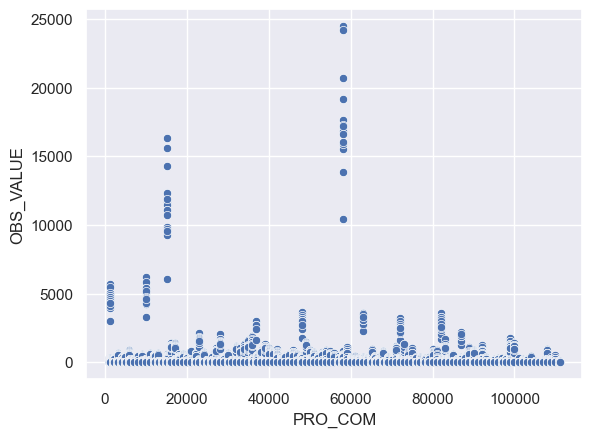

In [29]:
sns.scatterplot(x='PRO_COM', y='OBS_VALUE', data=df_analisi)
plt.show()

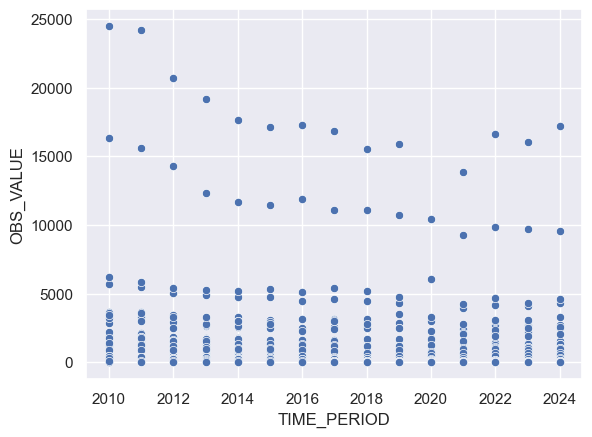

In [30]:
sns.scatterplot(x='TIME_PERIOD', y='OBS_VALUE', data=df_analisi)
plt.show()

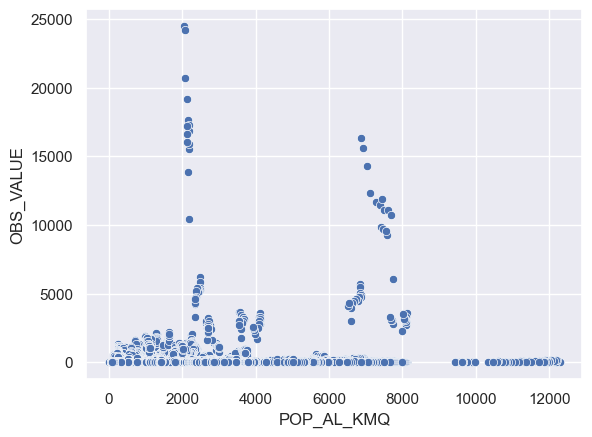

In [31]:
sns.scatterplot(x='POP_AL_KMQ', y='OBS_VALUE', data=df_analisi)
plt.show()

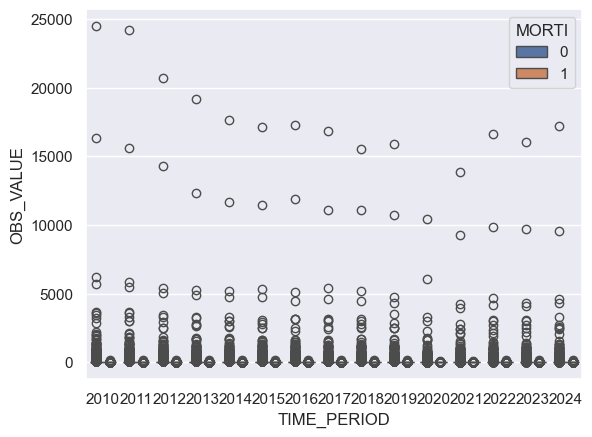

In [32]:
#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE',  data = df_analisi)
sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
plt.show()

In [33]:

#for feature in ['TIME_PERIOD','PRO_COM','POP_AL_KMQ']:
#    sns.boxplot(x=feature, y='MORTI', hue='OBS_VALUE', data = df_analisi)
#    plt.show()

#ANALISI CON MODELLO STATISTICO

dai grafici non ho una relazione lineare ma lo dimostro con i valori statistici restituiti dal modello

##PREPARAZIONE DATASET DI ANALISI, TRAINING E TEST

In [20]:
# definizione delle variabile dipendente - target
Y_Target = df_analisi['OBS_VALUE']

In [21]:
# definizione delle feature - variabili indipendenti
# nb come detto prima rimuovo 'PRO_COM',
X_Feature = df_analisi[['TIME_PERIOD','POP_AL_KMQ', 'MORTI']]

In [22]:
# aggiungo la costante
X_Feature = sm.add_constant(data=X_Feature)

In [23]:
# DEFINISCO GLI AMBIENTI DI TEST E TRAINING
X_train, X_test, Y_train, Y_test = envtest(X_Feature, Y_Target, test_size=0.3,random_state=2020)

In [24]:
#eseguo lo scaling ambiente Training
std_scaler = StandardScaler()
X_train_scaling = std_scaler.fit_transform(X_train)

In [25]:
#eseguo lo scaling ambiente test
std_scaler = StandardScaler()
X_test_scaling = std_scaler.fit_transform(X_test)

In [26]:
# definizione del modello statistico MULTI LINEAR REGRESSION
model_mlr= sm.OLS(Y_train ,X_train_scaling)

##ALLENAMENTO MODELLO

In [27]:
#allenamento del modello
MLR_Risultato=model_mlr.fit()

## VALUTAZIONE MODELLO

In [28]:
#lettura statistiche E LETTURA DEI PARAMETRI INTERNI
MLR_Risultato.summary()

c:\Users\pietr\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              OBS_VALUE   R-squared (uncentered):                   0.041
Model:                            OLS   Adj. R-squared (uncentered):              0.041
Method:                 Least Squares   F-statistic:                              1178.
Date:                Mon, 18 May 2026   Prob (F-statistic):                        0.00
Time:                        19:27:12   Log-Likelihood:                     -5.7851e+05
No. Observations:               82677   AIC:                                  1.157e+06
Df Residuals:                   82674   BIC:                                  1.157e+06
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0          0        nan        nan           0           0
x1            -3.3375      0.921     -3.625      0.000      -5.142      -1.533
x2            52.5630      0.923     56.959      0.000      50.754      54.372
x3           -19.3032      0.923    -20.911      0.000     -21.112     -17.494
==============================================================================
Omnibus:                   262207.534   Durbin-Watson:                   1.973
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      43283012680.589
Skew:                          51.300   Prob(JB):                         0.00
Kurtosis:                    3546.154   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

#valutazione del modello

##premessa
Ottimizzazioni
	tutte le feature sono state riportate alla stessa scala tramite lo scaling standard
		
correlazione
	prendo visione della forza della relazione che esiste tra le feature tramite la correlazione di Pirson
	
gestione multicollinerarità
	per il basso nr di feature non ho voluto eseguire un confronto tra i modelli rimuovendo le feature più legate tra loro
	ho eseguito però l'unione di 2 feature legate tra loro per diminuire questo effetto:
		- Tot. pop.
		- Superfice
		
	dalla matrice di correlazione ho visionato una situazione abbastanza ottimale eccetto per la feature associata alla densità


Modello statistico OLS:
	Ordinary lease sqaure: metodo dei minimi quadrati
	modello basato sulla scelta del minore valore dei minimi quadrati--> retta che fornisce il valore di errore minimo (tra punto reale e quello previsionale)

##Risultato
Coefficiente di Determinazione
	serve ad indicarmi quanto il modello si migliore rispetto al modello statistico peggiore selezionabile basato sulla media
	
	con valore R2 = 0.5 si è pari a a quello della semplice media
	
	R-Quadro
		il valore R Quadro non lo considero per la presenza di più feature che vanno a influenzare il valore corretto in modo positivo, alzandone il valore
		
	R-Quadro Adjustment
		Considero R Quadro Adjustment che corregge il valore R Quadro verso il basso (penalizza in funzione del numero di feature inserite).
		Si evince che non vi ha una differenza di valori significativa tra R-Quadro e R-Quadro
		
		R2	 	= 0.041
		Adj. R2 = 0.041

		il valore è molto basso per cui si accetta l'ipotesi nulla per la quale non esiste una relazione tra le variabili indipendenti e quella dipendente

		Ma soprattuto che il modello non è adatto per i dati

P-Value
	guardo il valore % di P-value
	
	risulta essere minore del livello di significatività del 5%
	mi indica la probabilità di ottenere il valore dell'ipotesi nulla e quindi del valore del coefficiente (peso) assegnato alla feature a 0
	
	variabile ind.	feature			valore
	1				TIME_PERIOD		0%
	3				POP_AL_KMQ		0%
	4				MORTI			0%
	
	a parte tutto, tutte le feature indicano valori molto minori del livello di significativa impostato al 5%, e si può rifiutare l'ipotesi nulla per cui esiste una relazione tra la variabile dipendente e quelle indipendenti
	ma essendo il modello errato non le considero
	
F-statistic



MAE - errore assoluto medio

	altra metrica usata per la valutazione del modello statistico scelto è il MAE.
	scelta perchè idonea su questo tipo di modello matematico selto

	si guarda l'accuratezza del modello

	confrontando il valore reale con quello previsto tramite la differenza assoluta dei 2 valori e dividendolo per il nr di casi, si capisce quanto ci discostiamo da quello reale.

	ecco perchè calcoliamo quello di training e poi quello di test per vedere quanto miglioriamo o peggioriamo dalla situazione supervisionata

	inoltre sarà indice dell'eventuale presenza di overfitting.

	dai valori ottenuti,
	MAE Training 
	MAE Test 
	si vede un valore di miglioramento e soprattutto una differenza che non evidenzia un caso di overfitting.


Hyper Parametri
	lo strumento di analisi statistico scelto non ha iperparametri
	infatti non posso eseguire simulazioni con differenti parametri architetturali come può avvenire per Decision Tree e FFNN
	

##METRICHE DI PERFORMANCE DEL MODELLO MAE

In [29]:
# CALCOLO INDICE DI PERFORMANCE
# MAE - MEAN ABSOLUTE ERROR - ERRORE ASSOLUTO MEDIO
# MAE_TEST
def mae(y_reali, y_predetti):
    return round(np.mean(np.abs(y_reali - y_predetti)), 2)

###PREVISIONI SU DATASET DI VALUTAZIONE MODELLO

In [30]:
# eseguo le previsioni sui dati mai visti
Y_pred_test = MLR_Risultato.predict(X_test_scaling)

###RICAVO PERFORMANCE SU DATI DI TEST MAI VISTI DAL MODELLO

In [31]:
# MAE PREVISIONALE SU DATI DI TEST
MAE_TEST_SORG =  mae(Y_test , np.mean(Y_test))

In [32]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TEST_PREV =  mae(Y_test, np.mean(Y_pred_test))

In [33]:
print(f'MAE TEST SORGENTE       : {MAE_TEST_SORG}')
print(f'MAE TEST PREVISIONALE  : {MAE_TEST_PREV}')

MAE TEST SORGENTE       : 41.26
MAE TEST PREVISIONALE  : 31.25


###RICAVO PERFORMANCE SU DATI DI TRAININ VISTI DAL MODELLO

In [34]:
# leggo il valore di predizione sul dato di training
pred_train = MLR_Risultato.predict(X_train_scaling)

In [35]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TRAIN_SORG =  mae(Y_train, np.mean(Y_train))

In [36]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TRAIN_PREV =  mae(Y_train, np.mean(pred_train))

In [37]:
print(f'MAE TRAINING SORGENTE       : {MAE_TRAIN_SORG}')
print(f'MAE TRAINING PREVISIONALE  : {MAE_TRAIN_PREV}')

MAE TRAINING SORGENTE       : 41.46
MAE TRAINING PREVISIONALE  : 31.29


#METRICHE DI PERFORMANCE DEL MODELLO - CONFUSION MATRIX

In [54]:
# non applicabile perchè il target non assume valori booleani
#cm = metrics.confusion_matrix(Y_test, Y_pred_test)

#FORECAST 2027

##preparazione dei dati

In [55]:
df_analisi.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

#da correggere usando la base precostruita

In [ ]:
df_forecast  = pd.read_csv( pd_common.GetFolderAnalisi() + "//Forecast_Da_Calcolare.csv")

In [57]:
# semplificazione che non considero + valida:
# se prendo solo l'ultimo anno degli indicenti, non significa che il comune non esiste
# ma solo che non ha avuto morti e feriti
# quindi l'elenco lo prendo dai comuni 2026

In [58]:
df_comuni_2026.columns

Index(['Unnamed: 0', 'anno_riferimento', 'COD_UTS', 'PRO_COM', 'COMUNE',
       'AREA_KMQ', 'POP_RES'],
      dtype='object')

In [59]:
df_comuni_2026 = df_comuni_2026.drop('COD_UTS',axis=1)

In [60]:
df_comuni_2026 = df_comuni_2026.drop('COMUNE',axis=1)

In [61]:
df_comuni_2026[df_comuni_2026.anno_riferimento==2026]['anno_riferimento'].unique()

array([2026])

In [62]:
df_comuni_2026 = df_comuni_2026[df_comuni_2026.anno_riferimento==2026]

In [63]:
df_comuni_2026['anno_riferimento'].unique()

array([2026])

In [64]:
df_comuni_2026['anno_riferimento'].size

7895

In [65]:
df_comuni_2026 = df_comuni_2026.drop('anno_riferimento',axis=1)

In [66]:
df_comuni_2026.columns

Index(['Unnamed: 0', 'PRO_COM', 'AREA_KMQ', 'POP_RES'], dtype='object')

In [67]:
df_comuni_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7895 entries, 127754 to 135648
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7895 non-null   int64  
 1   PRO_COM     7895 non-null   int64  
 2   AREA_KMQ    7895 non-null   float64
 3   POP_RES     7895 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 308.4 KB


In [68]:
df_comuni_2026['POP_AL_KMQ']= round(df_comuni_2026['POP_RES'] / df_comuni_2026['AREA_KMQ'] ,2)

In [69]:
df_comuni_2026[['POP_RES','AREA_KMQ','POP_AL_KMQ']]

,POP_RES,AREA_KMQ,POP_AL_KMQ
127754,2585,13.1463,196.63
127755,3695,15.7393,234.76
127756,463,46.3316,9.99
127757,1624,11.7397,138.33
127758,6297,17.8741,352.30
...,...,...,...
135644,10490,88.0162,119.18
135645,982,31.0025,31.67
135646,3298,91.3873,36.09
135647,1015,36.4281,27.86


In [70]:
df_comuni_2026 = df_comuni_2026.drop('POP_RES',axis=1)

In [71]:
df_comuni_2026 = df_comuni_2026.drop('AREA_KMQ',axis=1)

In [72]:
df_comuni_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7895 entries, 127754 to 135648
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7895 non-null   int64  
 1   PRO_COM     7895 non-null   int64  
 2   POP_AL_KMQ  7895 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 246.7 KB


In [73]:
# semplificazione che non considero + valida:
# se prendo solo l'ultimo anno degli indicenti, non significa che il comune non esiste
# ma solo che non ha avuto morti e feriti
# quindi l'elenco lo prendo dai comuni 2026
#
# basato su dati degli incidenti filtrati
#df_forecast_feriti = df_analisi.groupby(['PRO_COM', 'POP_AL_KMQ'], as_index=False).size()
#
# basato su tutti i comuni
df_forecast_feriti = df_comuni_2026.copy()


In [74]:
df_forecast_feriti.head()

,Unnamed: 0,PRO_COM,POP_AL_KMQ
127754,127770,1001,196.63
127755,127771,1002,234.76
127756,127772,1003,9.99
127757,127773,1004,138.33
127758,127774,1006,352.30


In [75]:
df_forecast_feriti.reset_index()

,index,Unnamed: 0,PRO_COM,POP_AL_KMQ
0,127754,127770,1001,196.63
1,127755,127771,1002,234.76
2,127756,127772,1003,9.99
3,127757,127773,1004,138.33
4,127758,127774,1006,352.30
...,...,...,...,...
7890,135644,135661,119020,119.18
7891,135645,135662,119021,31.67
7892,135646,135663,119022,36.09
7893,135647,135664,119023,27.86


In [76]:
df_forecast_feriti['TIME_PERIOD']= 2027

In [77]:
df_forecast_feriti['OBS_VALUE']= 0

In [78]:
df_forecast_feriti['MORTI']= 0

In [79]:
df_forecast_feriti['RESULT']= 'F'

In [80]:
#presente se si eseguiva il group by dagli incidenti
#df_forecast_feriti = df_forecast_feriti.drop('size',axis=1)

In [81]:
df_forecast_feriti.columns

Index(['Unnamed: 0', 'PRO_COM', 'POP_AL_KMQ', 'TIME_PERIOD', 'OBS_VALUE',
       'MORTI', 'RESULT'],
      dtype='object')

In [82]:
df_analisi.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [83]:
# voglio il medesimo ordine delle colonne
df_forecast_feriti= df_forecast_feriti[['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI']]

In [84]:
df_forecast_feriti.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI'], dtype='object')

In [85]:
df_forecast_morti = df_forecast_feriti.copy()

In [86]:
df_forecast_morti['RESULT']= 'M'

In [87]:
df_forecast_morti['MORTI']= 1

In [88]:
df_forecast_morti.head(5)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
127754,2027,1001,196.63,M,0,1
127755,2027,1002,234.76,M,0,1
127756,2027,1003,9.99,M,0,1
127757,2027,1004,138.33,M,0,1
127758,2027,1006,352.30,M,0,1


In [89]:
df_forecast = pd.concat([df_forecast_feriti, df_forecast_morti])

In [90]:
df_forecast.sample(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
132519,2027,59017,134.80,M,0,1
128710,2027,6118,38.65,M,0,1
134540,2027,85012,59.88,F,0,0


In [91]:
df_forecast_feriti.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
127754,2027,1001,196.63,F,0,0
127755,2027,1002,234.76,F,0,0
127756,2027,1003,9.99,F,0,0


In [92]:
df_forecast_morti.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
127754,2027,1001,196.63,M,0,1
127755,2027,1002,234.76,M,0,1
127756,2027,1003,9.99,M,0,1


In [93]:
rows_feriti, columns = df_forecast_feriti.shape
print(rows_feriti)

7895


In [94]:
rows_morti, columns = df_forecast_morti.shape
print(rows_morti)

7895


In [95]:
rows_forecast, columns = df_forecast.shape
print(rows_forecast)

15790


In [96]:
print(f'{str(rows_feriti + rows_morti)}')

15790


In [97]:
df_forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI'], dtype='object')

In [98]:
df_forecast = df_forecast.reset_index()

In [99]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [100]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
0,127754,2027,1001,196.63,F,0,0
1,127755,2027,1002,234.76,F,0,0
2,127756,2027,1003,9.99,F,0,0
3,127757,2027,1004,138.33,F,0,0
4,127758,2027,1006,352.30,F,0,0


In [101]:
df_forecast.head(5)['index']

0    127754
1    127755
2    127756
3    127757
4    127758
Name: index, dtype: int64

## preparo la stima del forecast

In [102]:
# definizione della variabile dipendente - target
Y_Target_Forecast = df_forecast['OBS_VALUE']

In [103]:
# definizione delle feature - variabili indipendenti
X_Feature_Forecast = df_forecast[[ 'TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']]

In [104]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [105]:
X_Feature_Forecast.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,MORTI
0,2027,1001,196.63,0
1,2027,1002,234.76,0
2,2027,1003,9.99,0


In [106]:
# aggiungo la costante
X_Feature_Forecast = sm.add_constant(data=X_Feature_Forecast)

In [107]:
X_train.columns

Index(['const', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [108]:
X_train.const.unique()

array([1.])

In [109]:
# non ha fatto l'aggiunta della costante, quindi la inserisco io
X_Feature_Forecast['const'] = 1.

In [110]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI', 'const'], dtype='object')

In [111]:
X_Feature_Forecast.const.unique()

array([1.])

In [112]:
#riordino i dati
X_Feature_Forecast = X_Feature_Forecast[['const', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI']]

In [113]:
#eseguo lo scaling ambiente Training
std_scaler_forecast = StandardScaler()
X_Feature_Forecast_Scaling = std_scaler_forecast.fit_transform(X_Feature_Forecast)

In [114]:
X_train_scaling

array([[ 0.        , -0.21465783, -1.27436147, -0.39552809, -0.52246744],
       [ 0.        , -0.90515916,  0.86446443, -0.31290811,  1.91399488],
       [ 0.        ,  1.16634484, -1.30501979, -0.22145965, -0.52246744],
       ...,
       [ 0.        ,  1.62667907, -0.72660362, -0.46625057, -0.52246744],
       [ 0.        ,  0.24567639, -0.0935843 , -0.38280588,  1.91399488],
       [ 0.        ,  1.62667907, -0.69981355,  0.10726268,  1.91399488]],
      shape=(82677, 5))

In [115]:
X_Feature_Forecast_Scaling

array([[ 0.        ,  0.        , -1.32126053, -0.16089699, -1.        ],
       [ 0.        ,  0.        , -1.32123123, -0.10080998, -1.        ],
       [ 0.        ,  0.        , -1.32120193, -0.45501287, -1.        ],
       ...,
       [ 0.        ,  0.        ,  2.13658662, -0.41388329,  1.        ],
       [ 0.        ,  0.        ,  2.13661592, -0.4268525 ,  1.        ],
       [ 0.        ,  0.        ,  2.13664522, -0.45034837,  1.        ]],
      shape=(15790, 5))

## eseguo la stima del forecast

In [116]:
# eseguo la previsione sul forecast
#utilizzo il modello allenato con il 70% dei dati storici
Y_pred_forecast = MLR_Risultato.predict(X_Feature_Forecast_Scaling)

##riporto la stima nei dati di forecast

In [117]:
#aggiungo la colonna row_num sul forecast per permettermi di asociare il target ai valori sorgenti
df_forecast["row_num"] = range(len(df_forecast))

In [118]:
type(Y_pred_forecast)

numpy.ndarray

In [119]:
dfforecast_target = df = pd.DataFrame({
    "row_num": range(len(Y_pred_forecast)),
    "target": Y_pred_forecast
})

In [120]:
dfforecast_target.columns

Index(['row_num', 'target'], dtype='object')

In [121]:
dfforecast_target.head(5)

,row_num,target
0,0,9.148045
1,1,12.305872
2,2,-6.308728
3,3,4.319965
4,4,22.040265


In [122]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'row_num'],
      dtype='object')

In [123]:
df_forecast.head(4)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num
0,127754,2027,1001,196.63,F,0,0,0
1,127755,2027,1002,234.76,F,0,0,1
2,127756,2027,1003,9.99,F,0,0,2
3,127757,2027,1004,138.33,F,0,0,3


In [124]:
dfforecast_target.head(4)

,row_num,target
0,0,9.148045
1,1,12.305872
2,2,-6.308728
3,3,4.319965


In [125]:
df_forecast = df_forecast.merge(dfforecast_target[['row_num','target']],
                                            how='inner',
                                            left_on='row_num',
                                            right_on='row_num')

In [126]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'row_num', 'target'],
      dtype='object')

In [127]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target
0,127754,2027,1001,196.63,F,0,0,0,9.148045
1,127755,2027,1002,234.76,F,0,0,1,12.305872
2,127756,2027,1003,9.99,F,0,0,2,-6.308728
3,127757,2027,1004,138.33,F,0,0,3,4.319965
4,127758,2027,1006,352.30,F,0,0,4,22.040265


In [128]:
df_forecast["target_int"] = np.floor(df["target"]).astype(int)

In [129]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,127754,2027,1001,196.63,F,0,0,0,9.148045,9
1,127755,2027,1002,234.76,F,0,0,1,12.305872,12
2,127756,2027,1003,9.99,F,0,0,2,-6.308728,-7
3,127757,2027,1004,138.33,F,0,0,3,4.319965,4
4,127758,2027,1006,352.30,F,0,0,4,22.040265,22


In [130]:
df_forecast.loc[df_forecast["target_int"] <0,'target_int']=0

In [131]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,127754,2027,1001,196.63,F,0,0,0,9.148045,9
1,127755,2027,1002,234.76,F,0,0,1,12.305872,12
2,127756,2027,1003,9.99,F,0,0,2,-6.308728,0
3,127757,2027,1004,138.33,F,0,0,3,4.319965,4
4,127758,2027,1006,352.30,F,0,0,4,22.040265,22


In [132]:
df_forecast[df_forecast['target_int']>0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,127754,2027,1001,196.63,F,0,0,0,9.148045,9
1,127755,2027,1002,234.76,F,0,0,1,12.305872,12
3,127757,2027,1004,138.33,F,0,0,3,4.319965,4
4,127758,2027,1006,352.30,F,0,0,4,22.040265,22
6,127760,2027,1008,1383.81,F,0,0,6,107.466272,107
...,...,...,...,...,...,...,...,...,...,...
15701,135560,2027,118006,1729.38,M,0,1,15701,101.911032,101
15709,135568,2027,118014,675.31,M,0,1,15709,14.617072,14
15723,135582,2027,118028,2911.20,M,0,1,15723,199.785942,199
15733,135592,2027,118038,706.93,M,0,1,15733,17.236652,17


In [133]:
# prendo i soli dati significativi
df_forecast = df_forecast[df_forecast['target_int']>0]

In [134]:
df_forecast[df_forecast['target_int']<0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int


In [135]:
df_forecast['OBS_VALUE'] = df_forecast['target_int']

In [136]:
df_forecast[df_forecast['target_int']>0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,127754,2027,1001,196.63,F,9,0,0,9.148045,9
1,127755,2027,1002,234.76,F,12,0,1,12.305872,12
3,127757,2027,1004,138.33,F,4,0,3,4.319965,4
4,127758,2027,1006,352.30,F,22,0,4,22.040265,22
6,127760,2027,1008,1383.81,F,107,0,6,107.466272,107
...,...,...,...,...,...,...,...,...,...,...
15701,135560,2027,118006,1729.38,M,101,1,15701,101.911032,101
15709,135568,2027,118014,675.31,M,14,1,15709,14.617072,14
15723,135582,2027,118028,2911.20,M,199,1,15723,199.785942,199
15733,135592,2027,118038,706.93,M,17,1,15733,17.236652,17


In [137]:
df_forecast = df_forecast.drop(['row_num','target','target_int'],axis=1)

In [138]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5766 entries, 0 to 15743
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        5766 non-null   int64  
 1   TIME_PERIOD  5766 non-null   int64  
 2   PRO_COM      5766 non-null   int64  
 3   POP_AL_KMQ   5766 non-null   float64
 4   RESULT       5766 non-null   object 
 5   OBS_VALUE    5766 non-null   int64  
 6   MORTI        5766 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 360.4+ KB


In [139]:
df_forecast['RESULT'] = df_forecast['RESULT'].astype('string')

In [140]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5766 entries, 0 to 15743
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        5766 non-null   int64  
 1   TIME_PERIOD  5766 non-null   int64  
 2   PRO_COM      5766 non-null   int64  
 3   POP_AL_KMQ   5766 non-null   float64
 4   RESULT       5766 non-null   string 
 5   OBS_VALUE    5766 non-null   int64  
 6   MORTI        5766 non-null   int64  
dtypes: float64(1), int64(5), string(1)
memory usage: 360.4 KB


##riporto la stima nei dati degli incidenti

In [141]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

In [142]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [143]:
df_comuni_flat = pd.read_csv( ".//Analisi//ElencoComuniProvinceRegioniRipGeografiche.csv")

In [144]:
df_comuni_flat.columns


Index(['Unnamed: 0', 'anno_riferimento', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ'],
      dtype='object')

In [145]:
df_comuni_flat = df_comuni_flat[df_comuni_flat['anno_riferimento']==2026]

In [146]:
df_comuni_flat.anno_riferimento.unique()

array([2026])

In [ ]:
#assegno l'ambito dei dati ottenuti da istat come storico
df_incidenti['TIPO_DATO'] ='S'
df_incidenti['TIPO_DATO_DSC'] ='Storico'

In [ ]:
#assegno l'ambito dei dati forecast come appunto di forecast
df_forecast['TIPO_DATO'] ='F'
df_forecast['TIPO_DATO_DSC'] ='Forecast'

In [149]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [150]:
df_forecast = df_forecast.merge(df_comuni_flat[['PRO_COM',
                                                'COD_RIP', 'DEN_RIP',
                                                'COD_REG', 'DEN_REG',
                                                'COD_UTS', 'DEN_UTS',
                                                'COMUNE',
                                                'AREA_KMQ','POP_RES']],
                                            how='inner',
                                            left_on='PRO_COM',
                                            right_on='PRO_COM')

In [151]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'TIPO_DATO', 'TIPO_DATO_DSC', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'COMUNE', 'AREA_KMQ', 'POP_RES'],
      dtype='object')

In [152]:
df_forecast.TIME_PERIOD.unique()

array([2027])

In [153]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

In [154]:
df_incidenti.drop('index', axis=1)

,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,COMUNE,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC
0,2010,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2622,199.45,F,Feriti,14,S,Storico
1,2011,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2615,198.92,F,Feriti,6,S,Storico
2,2012,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2657,202.11,F,Feriti,8,S,Storico
3,2013,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2722,207.06,F,Feriti,5,S,Storico
4,2014,1,Nord-ovest,1,Piemonte,1,Torino,1001,Agliè,13.1462,2748,209.03,F,Feriti,11,S,Storico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118106,2021,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1937,2549,93.73,F,Feriti,7,S,Storico
118107,2022,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2536,93.25,F,Feriti,1,S,Storico
118108,2023,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2575,94.69,F,Feriti,5,S,Storico
118109,2024,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2616,96.20,F,Feriti,5,S,Storico


In [155]:
df_forecast['RESULT_DESC']='Feriti'

In [156]:
df_forecast.loc[df_forecast['RESULT']=='M','RESULT_DESC'] = 'Morti'

In [157]:
df_forecast.groupby(['RESULT','RESULT_DESC']).agg('size')

RESULT  RESULT_DESC
F       Feriti         4684
M       Morti          1082
dtype: int64

In [158]:
df_forecast = df_forecast[['TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC']]

In [159]:
incidenti_forecast = pd.concat([df_incidenti, df_forecast])

In [160]:
incidenti_forecast.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

In [161]:
incidenti_forecast.TIME_PERIOD.unique()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2017, 2027])

In [ ]:
#caso vs:
#   importare le librerie come negli altri file
#  pd_common.SalvaDataset(df_incidenti_flat_an, f"Incidenti_flat",False)
#
incidenti_forecast.to_csv('.//Analisi//Incidenti_Con_Forecast_flat.csv')

##Aggiunta della nuova tabella dimensionale relativa al periodo di riferimento dei dati

In [163]:
df_periodo = incidenti_forecast.groupby(['TIPO_DATO', 'TIPO_DATO_DSC'], as_index=False).size()

In [168]:
df_periodo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TIPO_DATO      2 non-null      string
 1   TIPO_DATO_DSC  2 non-null      object
dtypes: object(1), string(1)
memory usage: 164.0+ bytes


In [165]:
df_periodo = df_periodo.drop('size',axis=1)

In [170]:
df_periodo['TIPO_DATO'] = df_periodo['TIPO_DATO'].astype('string')
df_periodo['TIPO_DATO_DSC'] = df_periodo['TIPO_DATO_DSC'].astype('string')

In [171]:
pd_common.SalvaDataset(df_periodo, f"PeriodoDato",False)

      path completo file:  c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv
      Il file 'c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv' non esiste
      Il file salvato c:\progetto_dataanalyst\progettofinale\Analisi/PeriodoDato.csv
